Dados do arquivo "resultado gridsearch.txt"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# Dados
# ============================

models = ["Regressão Logística", "MLP", "Naive Bayes"]
f1_val = [0.7737783817299011, 0.7957130393323781, np.nan]  # Naive Bayes N/A
f1_test = [0.7894201424211598, 0.8183556405353728, 0.7843137254901961]

reports = {
    "Regressão Logística": {
        0: {"precision": 0.59, "recall": 0.73, "f1": 0.66, "support": 270},
        1: {"precision": 0.84, "recall": 0.74, "f1": 0.79, "support": 523},
    },
    "MLP": {
        0: {"precision": 0.65, "recall": 0.65, "f1": 0.65, "support": 270},
        1: {"precision": 0.82, "recall": 0.82, "f1": 0.82, "support": 523},
    },
    "Naive Bayes": {
        0: {"precision": 0.58, "recall": 0.64, "f1": 0.61, "support": 270},
        1: {"precision": 0.80, "recall": 0.76, "f1": 0.78, "support": 523},
    }
}

In [2]:
# ============================
# Função para reconstruir matriz de confusão
# ============================

def reconstruct_confusion(report):
    s0 = report[0]["support"]
    s1 = report[1]["support"]

    tp0 = int(round(report[0]["recall"] * s0))
    tp1 = int(round(report[1]["recall"] * s1))

    fn0 = s0 - tp0
    fn1 = s1 - tp1

    cm = np.array([
        [tp0, fn0],
        [fn1, tp1]
    ])

    total = s0 + s1
    if cm.sum() != total:
        cm[1,1] += int(total - cm.sum())

    return cm

cms = {m: reconstruct_confusion(reports[m]) for m in models}

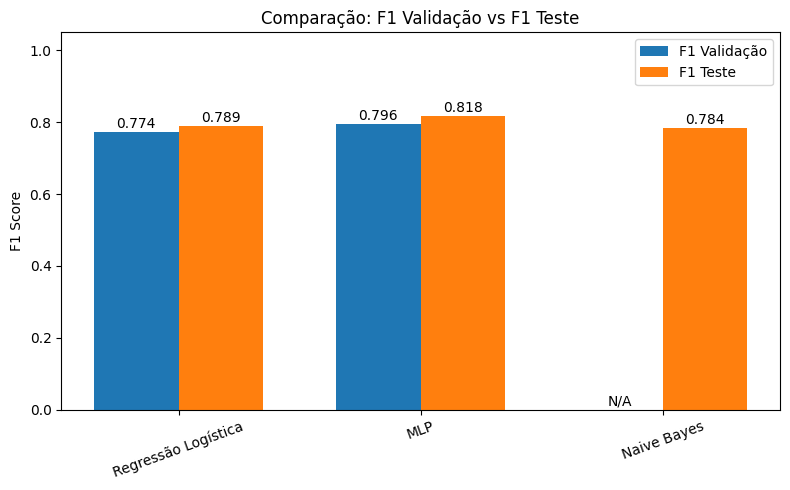

In [3]:
# ============================
# GRÁFICO 1 – F1 Validação vs Teste
# ============================

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, [v if not np.isnan(v) else 0 for v in f1_val], width, label="F1 Validação")
plt.bar(x + width/2, f1_test, width, label="F1 Teste")

plt.xticks(x, models, rotation=20)
plt.ylabel("F1 Score")
plt.title("Comparação: F1 Validação vs F1 Teste")
plt.legend()

for i, val in enumerate(f1_val):
    if np.isnan(val):
        plt.text(i - width/2, 0.01, "N/A", ha='center')
    else:
        plt.text(i - width/2, val + 0.01, f"{val:.3f}", ha='center')

for i, val in enumerate(f1_test):
    plt.text(i + width/2, val + 0.01, f"{val:.3f}", ha='center')

plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

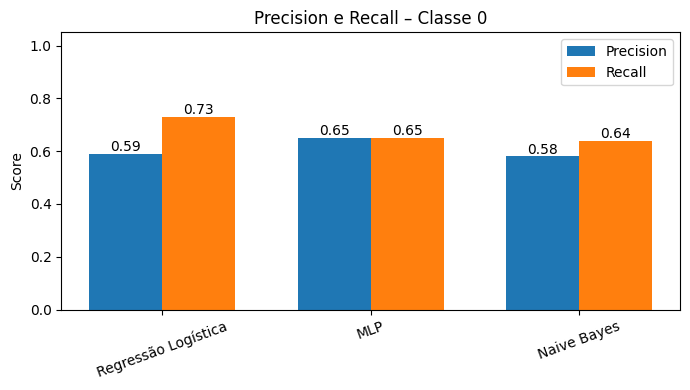

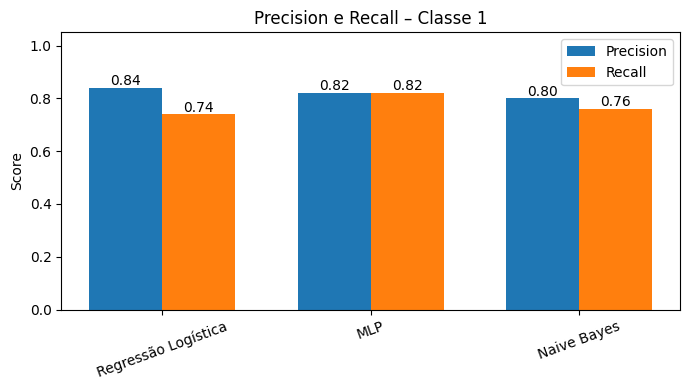

In [4]:
# ============================
# GRÁFICO 2 – Precision e Recall por classe
# ============================

classes = [0, 1]
width = 0.35

for cls in classes:
    plt.figure(figsize=(7,4))
    precs = [reports[m][cls]["precision"] for m in models]
    recs = [reports[m][cls]["recall"] for m in models]

    x = np.arange(len(models))

    plt.bar(x - width/2, precs, width, label="Precision")
    plt.bar(x + width/2, recs, width, label="Recall")

    plt.xticks(x, models, rotation=20)
    plt.title(f"Precision e Recall – Classe {cls}")
    plt.ylabel("Score")
    plt.legend()

    for i, v in enumerate(precs):
        plt.text(i - width/2, v + 0.01, f"{v:.2f}", ha="center")

    for i, v in enumerate(recs):
        plt.text(i + width/2, v + 0.01, f"{v:.2f}", ha="center")

    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

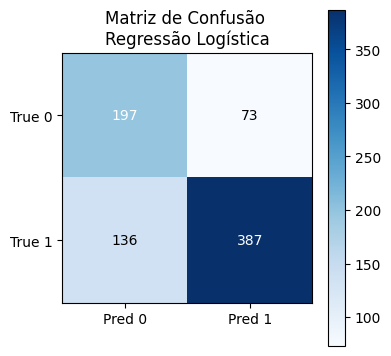

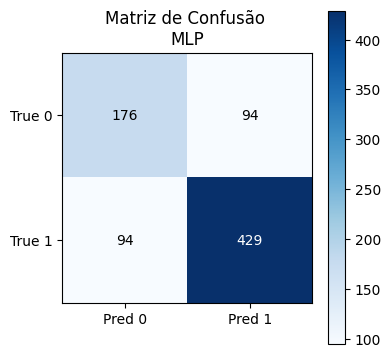

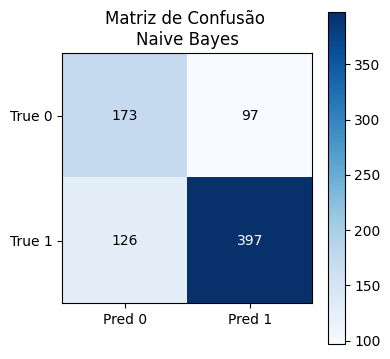

In [21]:
# ============================
# GRÁFICO 3 – Matrizes de Confusão
# ============================

for m in models:
    cm = cms[m]
    plt.figure(figsize=(4,4))

    plt.imshow(cm, cmap="Blues", interpolation="nearest", aspect="equal")

    plt.title(f"Matriz de Confusão \n{m}")


    plt.colorbar()

    ticks = [0,1]
    plt.xticks(ticks, ["Pred 0", "Pred 1"])
    plt.yticks(ticks, ["True 0", "True 1"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, int(cm[i,j]), ha="center", va="center",
                     color="white" if cm[i,j] > cm.max()/2 else "black")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [6]:
# ============================
# Tabela resumo
# ============================

summary = []
for i, m in enumerate(models):
    summary.append({
        "model": m,
        "f1_val": f"{f1_val[i]:.3f}" if not np.isnan(f1_val[i]) else "N/A",
        "f1_test": f"{f1_test[i]:.3f}",
        "precision_class0": reports[m][0]["precision"],
        "recall_class0": reports[m][0]["recall"],
        "precision_class1": reports[m][1]["precision"],
        "recall_class1": reports[m][1]["recall"],
        "support_class0": reports[m][0]["support"],
        "support_class1": reports[m][1]["support"]
    })

df_summary = pd.DataFrame(summary)
# Display dataframe
display(df_summary)

,model,f1_val,f1_test,precision_class0,recall_class0,precision_class1,recall_class1,support_class0,support_class1
0,Regressão Logística,0.774,0.789,0.59,0.73,0.84,0.74,270,523
1,MLP,0.796,0.818,0.65,0.65,0.82,0.82,270,523
2,Naive Bayes,N/A,0.784,0.58,0.64,0.80,0.76,270,523


In [7]:
# ============================
# FORMATAÇÃO DOS DADOS
# ============================

formatted = {}

for i, m in enumerate(models):
    formatted[m] = {
        "f1_test": f1_test[i],
        "f1_class": {
            0: reports[m][0]["f1"],
            1: reports[m][1]["f1"]
        },
        "precision": {
            0: reports[m][0]["precision"],
            1: reports[m][1]["precision"]
        },
        "recall": {
            0: reports[m][0]["recall"],
            1: reports[m][1]["recall"]
        },
        "support": {
            0: reports[m][0]["support"],
            1: reports[m][1]["support"]
        }
    }

In [8]:
# ============================
# ANÁLISE AGREGADA
# ============================

def confusion_from_recall_support(recall_dict, support_dict):
    """
    Reconstrói matriz de confusão igual ao reconstruct_confusion(),
    mas usando dicts simples de recall/support.
    """
    tp0 = int(round(recall_dict[0] * support_dict[0]))
    tp1 = int(round(recall_dict[1] * support_dict[1]))

    fn0 = support_dict[0] - tp0
    fn1 = support_dict[1] - tp1

    cm = np.array([
        [tp0, fn0],
        [fn1, tp1]
    ])

    total = support_dict[0] + support_dict[1]
    if cm.sum() != total:
        cm[1,1] += int(total - cm.sum())

    return cm

def summary_analysis(models_input):
    print("\n\n===== Análise agregada dos modelos (resumo) =====\n")

    # Ranking por F1 teste
    rank = sorted(models_input.items(),
                  key=lambda kv: kv[1]["f1_test"],
                  reverse=True)

    print("Ranking por F1 (teste):")
    for i, (name, info) in enumerate(rank, 1):
        print(f"{i}. {name} — F1 teste: {info['f1_test']:.4f}")

    # Média de F1 por classe
    cls0_mean = np.mean([info["f1_class"][0] for _, info in models_input.items()])
    cls1_mean = np.mean([info["f1_class"][1] for _, info in models_input.items()])

    print(f"\nMédia F1 classe 0: {cls0_mean:.3f}")
    print(f"Média F1 classe 1: {cls1_mean:.3f}")

    if cls0_mean < cls1_mean:
        print("\nConclusão: Classe 0 é, em média, mais difícil para os modelos (menor F1).")
    else:
        print("\nConclusão: Classe 1 é, em média, mais difícil para os modelos.")

    # Erros por classe usando matrizes reconstruídas
    for name, info in models_input.items():
        cm = confusion_from_recall_support(info["recall"], info["support"])
        tp0, fn0 = cm[0]
        fn1, tp1 = cm[1]

        print(f"\nModelo: {name}")
        print(f" - Classe 0: TP={tp0}, FN={fn0}, taxa de erro={(fn0/info['support'][0]):.3f}")
        print(f" - Classe 1: TP={tp1}, FN={fn1}, taxa de erro={(fn1/info['support'][1]):.3f}")

# ============================
# EXECUTA ANÁLISE
# ============================

summary_analysis(formatted)




===== Análise agregada dos modelos (resumo) =====

Ranking por F1 (teste):
1. MLP — F1 teste: 0.8184
2. Regressão Logística — F1 teste: 0.7894
3. Naive Bayes — F1 teste: 0.7843

Média F1 classe 0: 0.640
Média F1 classe 1: 0.797

Conclusão: Classe 0 é, em média, mais difícil para os modelos (menor F1).

Modelo: Regressão Logística
 - Classe 0: TP=197, FN=73, taxa de erro=0.270
 - Classe 1: TP=387, FN=136, taxa de erro=0.260

Modelo: MLP
 - Classe 0: TP=176, FN=94, taxa de erro=0.348
 - Classe 1: TP=429, FN=94, taxa de erro=0.180

Modelo: Naive Bayes
 - Classe 0: TP=173, FN=97, taxa de erro=0.359
 - Classe 1: TP=397, FN=126, taxa de erro=0.241
